In [1]:
# Instalando o Ultralytics para usar junto com o YOLOv8
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [2]:
# FAzendo os imports
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import time
from ultralytics import YOLO
from IPython.display import display, Image
from IPython import display

display.clear_output()


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("orvile/human-bone-fractures-image-dataset-hbfmid")

print("Path to dataset files:", path)

100%|██████████| 38.1M/38.1M [00:02<00:00, 14.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/orvile/human-bone-fractures-image-dataset-hbfmid/versions/1


In [7]:
# treinando o yolo utilizando um dataset encontrado em https://www.kaggle.com/datasets/ultralytics/brain-tumor sobre tumores cerebrais
!yolo task=detect mode=train model=yolov8m.pt data="/root/.cache/kagglehub/datasets/orvile/human-bone-fractures-image-dataset-hbfmid/versions/1/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml" epochs=50 imgsz=640


Ultralytics 8.3.121 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/root/.cache/kagglehub/datasets/orvile/human-bone-fractures-image-dataset-hbfmid/versions/1/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False

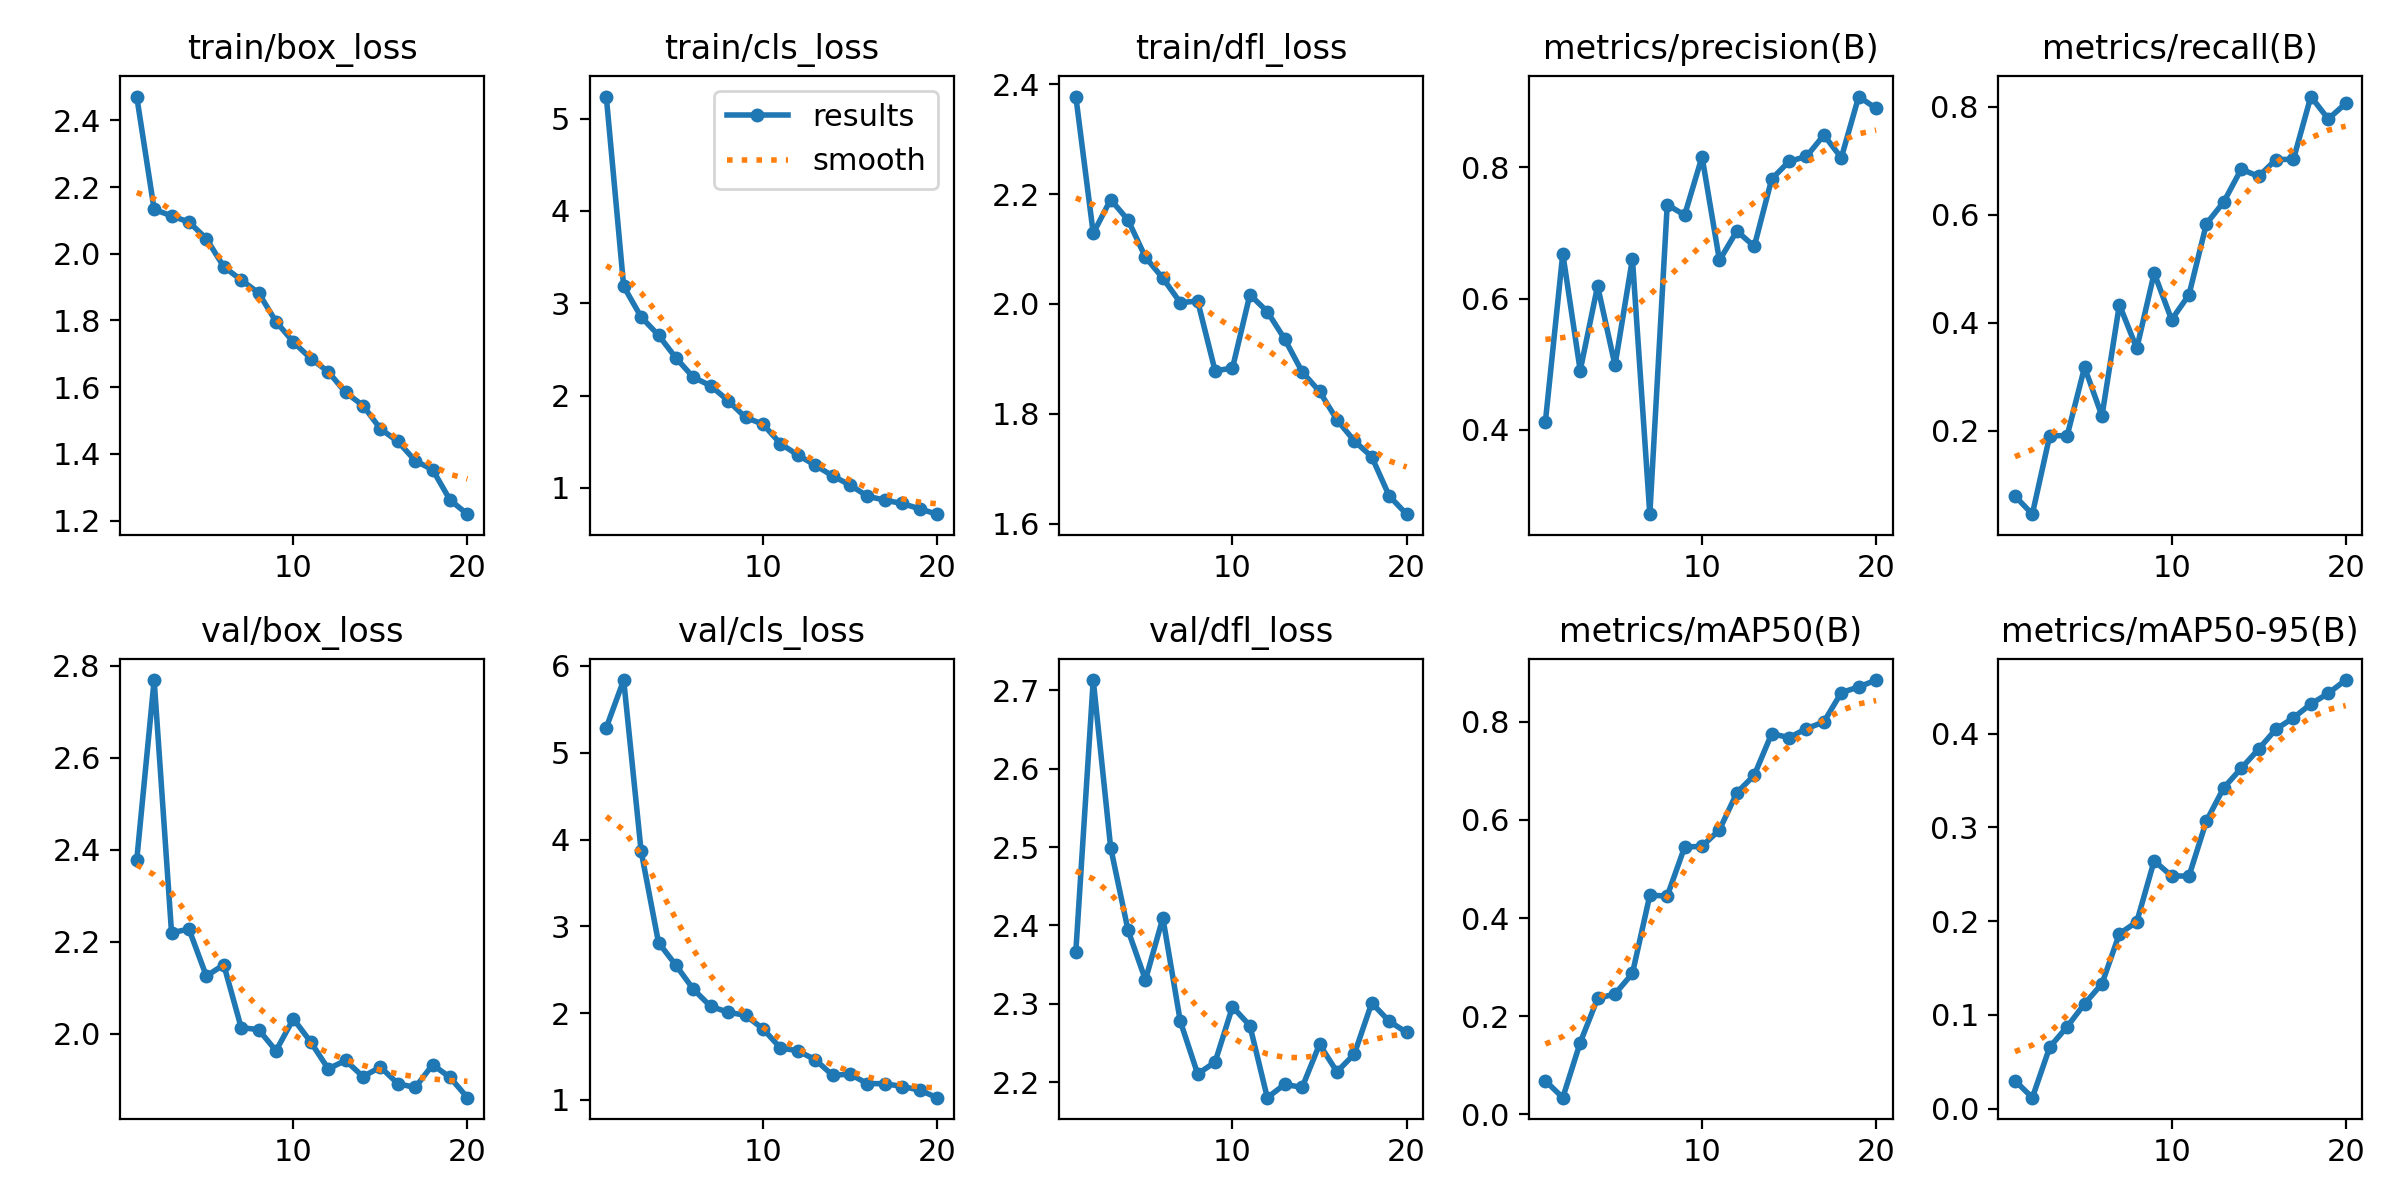

In [5]:
# vendo os resultados
Image(filename = f"/content/runs/detect/train/results.png")

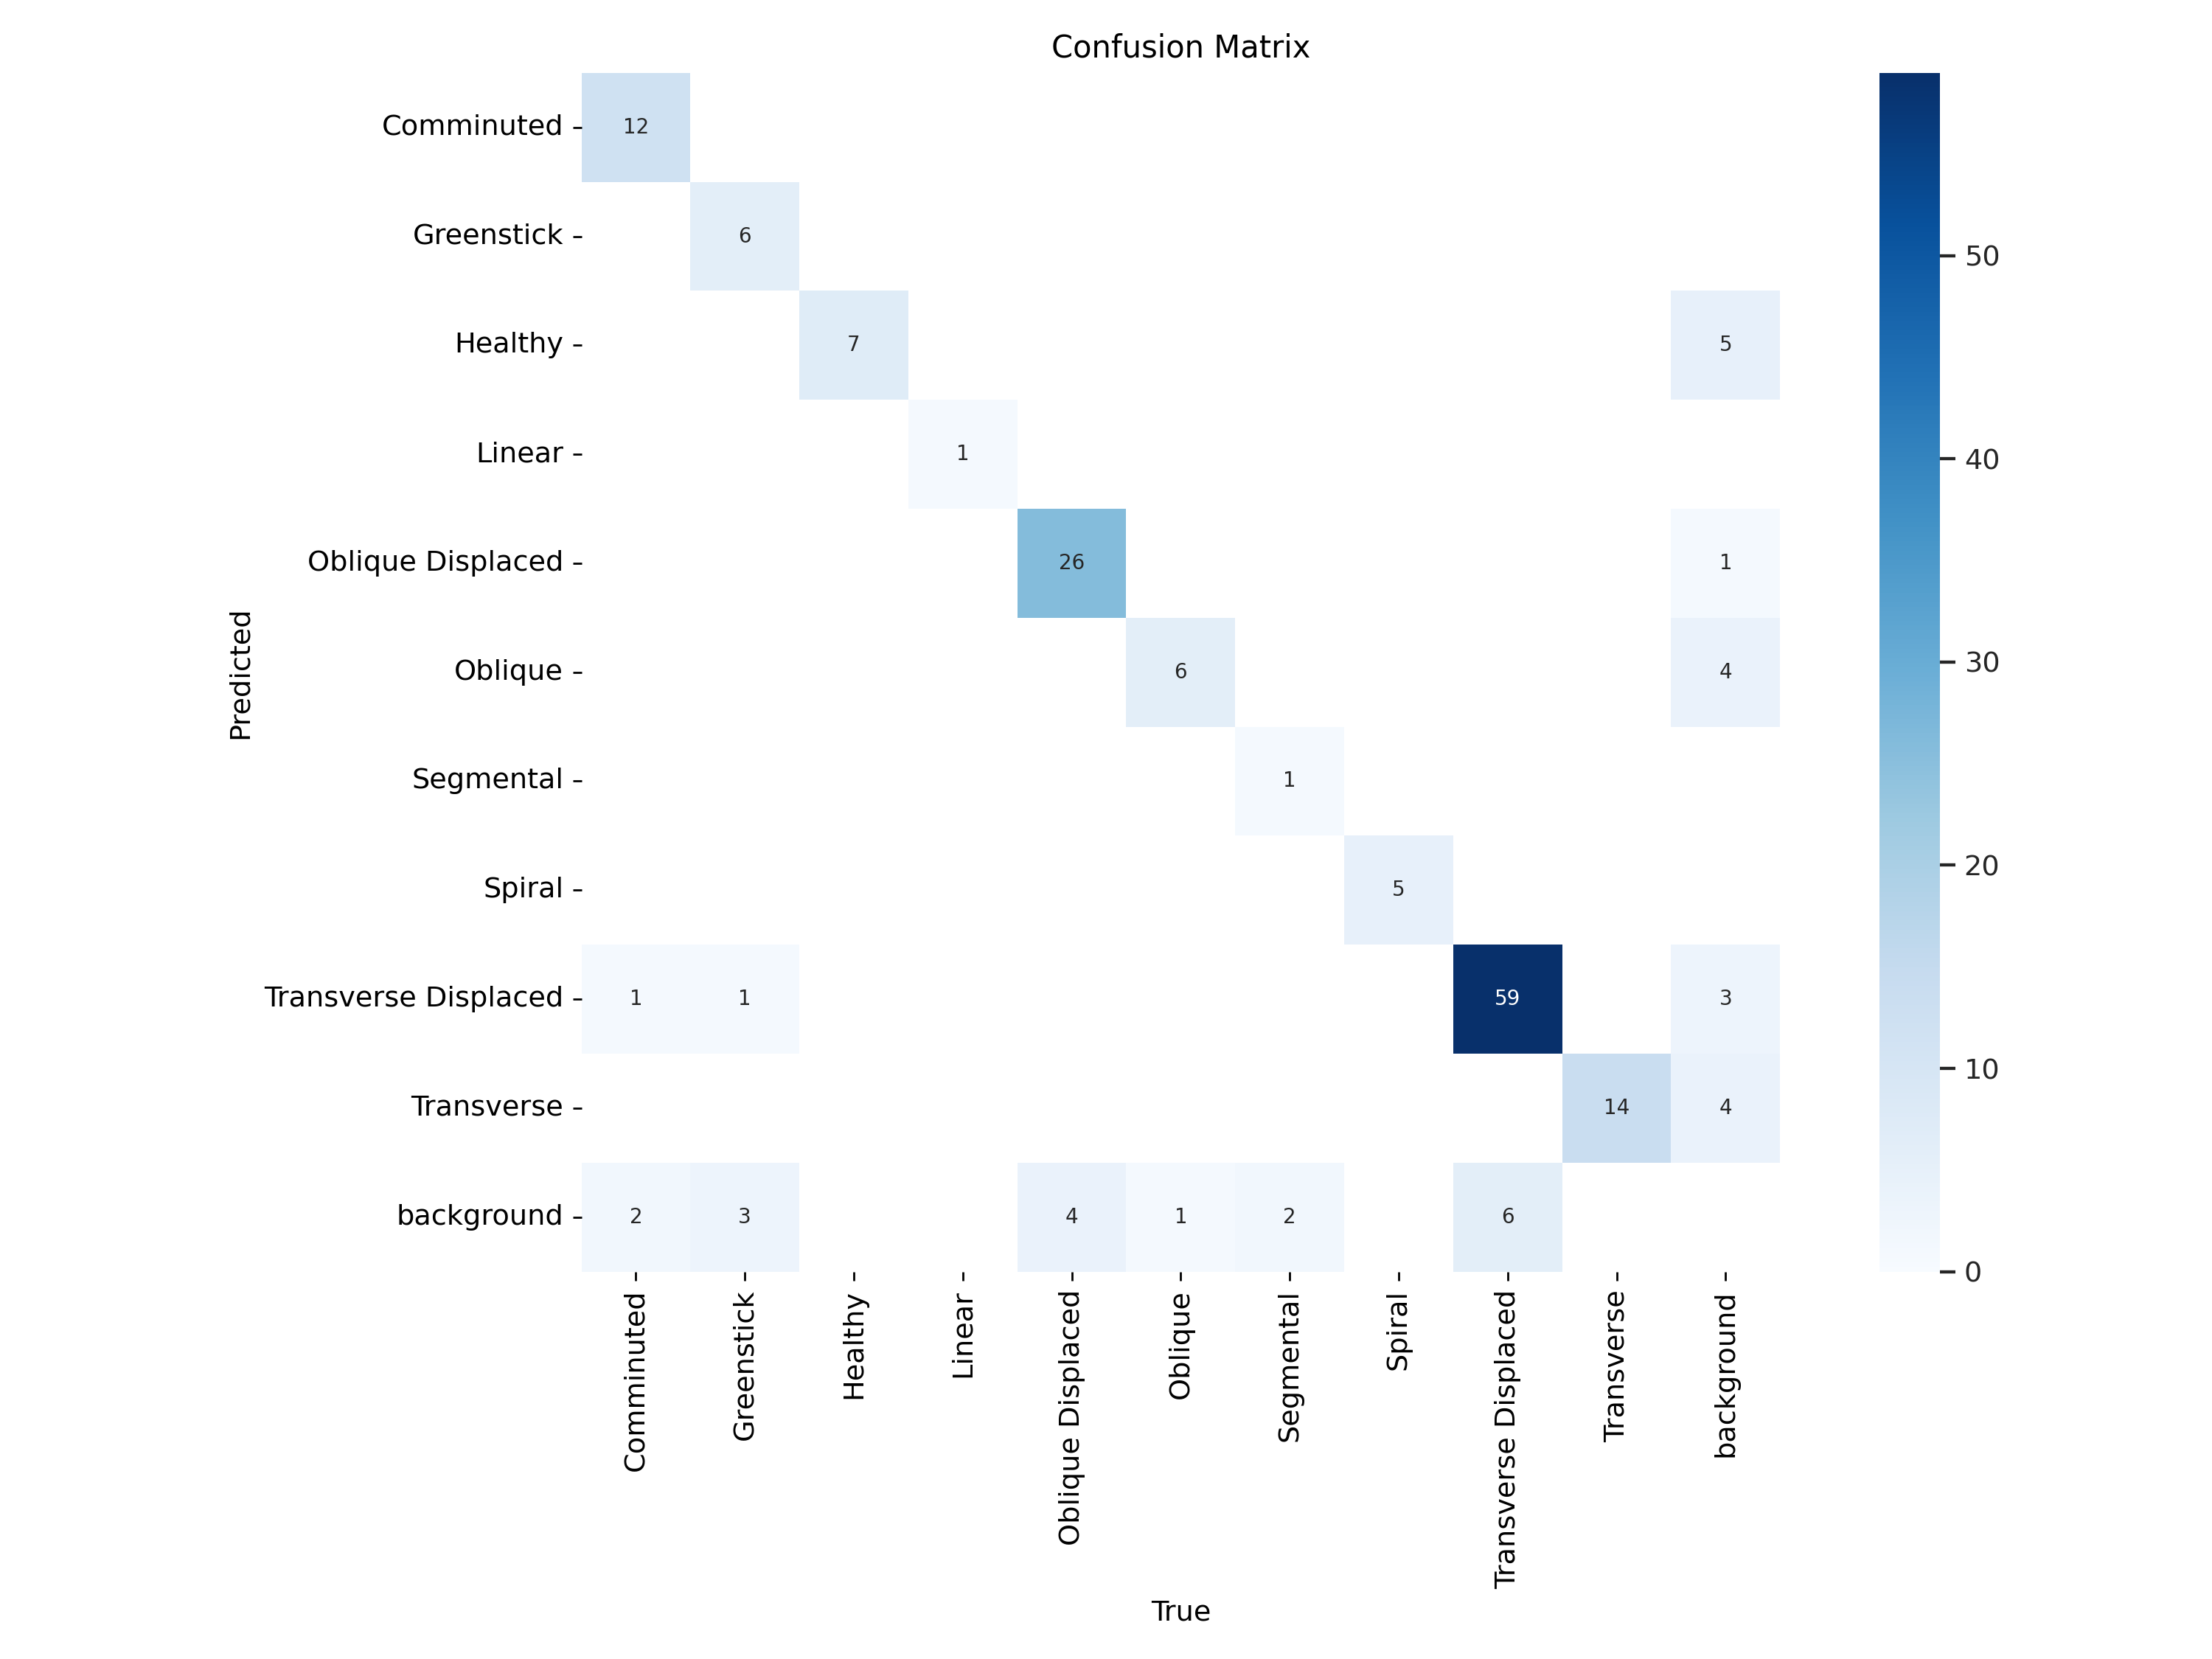

In [8]:
# mostrando a matriz de confusão
Image(filename = f"/content/runs/detect/train/confusion_matrix.png")

In [9]:
# validando o modelo
!yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data="/root/.cache/kagglehub/datasets/orvile/human-bone-fractures-image-dataset-hbfmid/versions/1/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml"

Ultralytics 8.3.121 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 857.7±201.1 MB/s, size: 25.0 KB)
val: Scanning /root/.cache/kagglehub/datasets/orvile/human-bone-fractures-image-dataset-hbfmid/versions/1/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/labels.cache... 128 images, 0 backgrounds, 0 corrupt: 100% 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 8/8 [00:04<00:00,  1.66it/s]
                   all        128        157       0.89      0.806      0.886      0.456
            Comminuted         15         15          1      0.761      0.875       0.54
            Greenstick         10         10      0.814      0.441      0.477      0.168
               Healthy          7          7      0.827          1      0.978      0